<a href="https://colab.research.google.com/github/Elvis-Kayonga/Data-Preprocessing-Formative2-ML-GROUP9/blob/main/FaceRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q images.zip

Add a Text Cell and paste this explanation so your professor knows what the next block does:

  **Step 1: Import Tools and Load the AI Brain**

  Here, we import the necessary libraries for image processing (OpenCV) and data manipulation (Pandas). We also load MobileNetV2, a pre-trained deep learning model, which will help us extract highly accurate facial embeddings from our pictures.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Loading the AI Model
print("Loading the AI model...")
embedding_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
print("Model loaded successfully!")

Loading the AI model...


/tmp/ipykernel_1043/438364156.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  embedding_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


Model loaded successfully!


**Step 2: Build the Core Functions
  We need three functions to handle our images.**

  display_sample_images to prove our data loaded correctly.

  extract_features to pull the color histograms and AI embeddings from a single image.

  process_and_augment to take one original image, create a grayscale and a flipped version, and extract features from all three.

In [ ]:
def display_sample_images(image_paths, member_name):
    """Displays up to 3 sample images for a specific group member."""
    # I made the figure slightly taller (from 3 to 4) to give text more room
    plt.figure(figsize=(10, 4))

    for i, path in enumerate(image_paths[:3]):
        img = cv2.imread(path)
        if img is not None:
            # Fix colors for matplotlib
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(1, 3, i + 1)
            plt.imshow(img)
            plt.title(f"{member_name} - Image {i+1}")
            plt.axis('off')

    # Added y=1.05 to push the main title up, away from the picture titles
    plt.suptitle(f"Sample Pictures: {member_name}", fontsize=14, fontweight='bold', y=1.05)

    # This magic command forces matplotlib to calculate proper spacing
    plt.tight_layout()
    plt.show()

def extract_features(image):
    """Extracts a color histogram and an AI embedding."""
    hist = cv2.calcHist([image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()

    img_resized = cv2.resize(image, (224, 224))
    img_array = img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    embedding = embedding_model.predict(img_array, verbose=0).flatten()
    return np.concatenate([hist, embedding])

def process_and_augment(image_path, label):
    """Applies 2 augmentations (grayscale & flip) and extracts features."""
    original_img = cv2.imread(image_path)
    if original_img is None:
        return []

    features_list = []

    # 1. Original
    features_list.append({'label': label, 'augmentation': 'none', 'features': extract_features(original_img)})

    # 2. Grayscale Augmentation
    gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    gray_img_3channel = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)
    features_list.append({'label': label, 'augmentation': 'grayscale', 'features': extract_features(gray_img_3channel)})

    # 3. Flipped Augmentation
    flipped_img = cv2.flip(original_img, 1)
    features_list.append({'label': label, 'augmentation': 'flipped', 'features': extract_features(flipped_img)})

    return features_list

Starting the image processing pipeline...

--> Processing folder: samuel


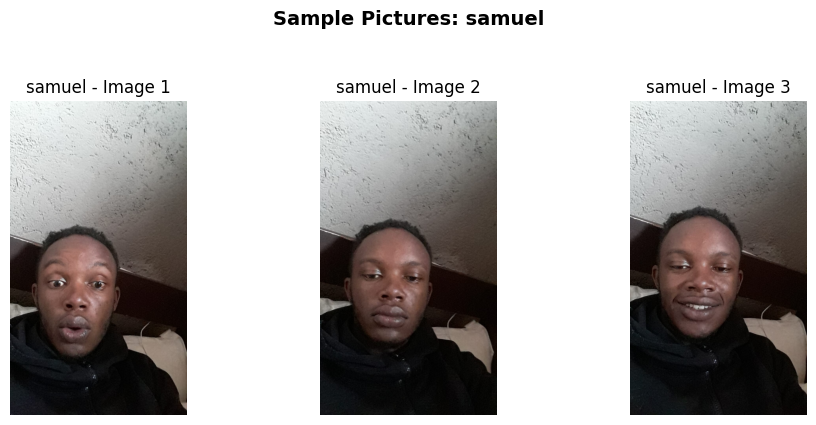

--> Processing folder: Sharif


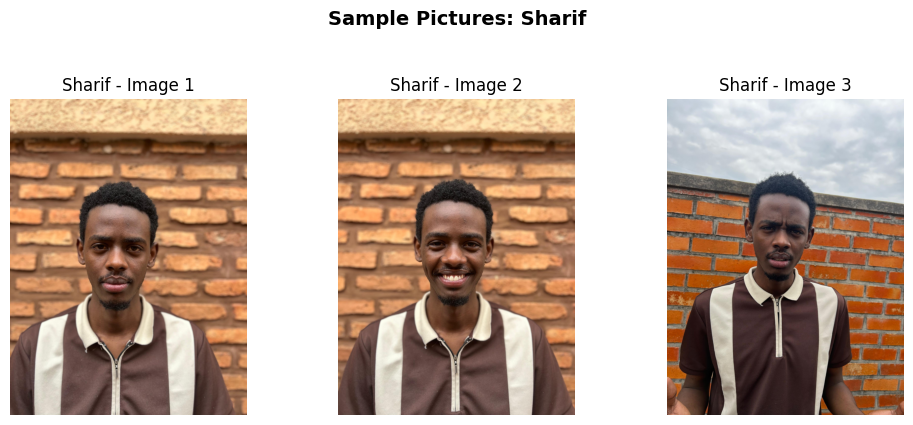

--> Processing folder: Paulette


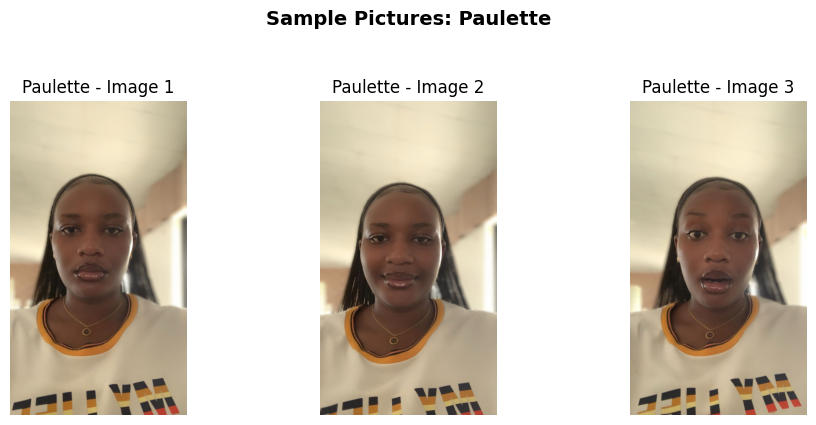

--> Processing folder: kayonga


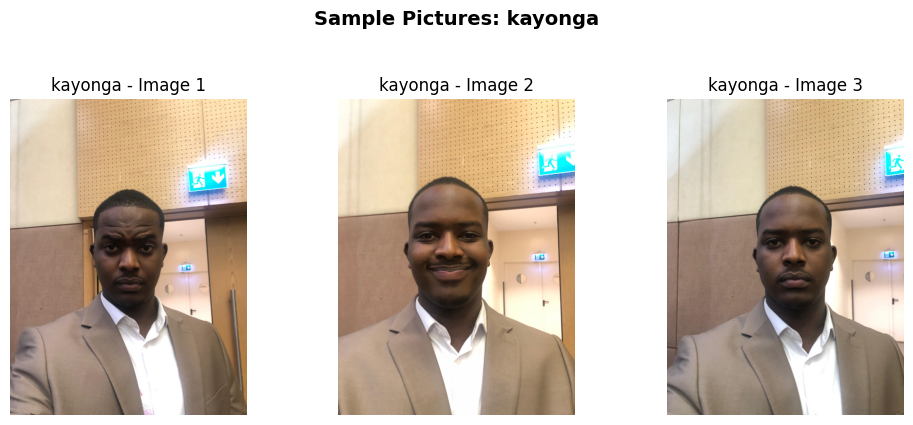

In [ ]:
image_dir = "images"
all_data = []

print("Starting the image processing pipeline...\n")

for member_name in os.listdir(image_dir):
    member_folder = os.path.join(image_dir, member_name)

    if os.path.isdir(member_folder):
        print(f"--> Processing folder: {member_name}")

        image_files = [os.path.join(member_folder, f) for f in os.listdir(member_folder)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if len(image_files) > 0:
            display_sample_images(image_files, member_name)

            for img_path in image_files:
                extracted_data = process_and_augment(img_path, label=member_name)
                all_data.extend(extracted_data)
        else:
            print(f"    Warning: No pictures found for {member_name}.")

In [ ]:
print("Formatting data for CSV export...")

formatted_data = []
for item in all_data:
    row = {'label': item['label'], 'augmentation': item['augmentation']}
    for i, val in enumerate(item['features']):
        row[f'feature_{i}'] = val
    formatted_data.append(row)

df = pd.DataFrame(formatted_data)
csv_filename = 'image_features.csv'
df.to_csv(csv_filename, index=False)

print(f"SUCCESS! Dataset shape: {df.shape}")
print(f"Saved perfectly to {csv_filename}. Ready to download!")

Formatting data for CSV export...
SUCCESS! Dataset shape: (36, 1794)
Saved perfectly to image_features.csv. Ready to download!


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss
import joblib

print("Loading the extracted image features...")
df = pd.read_csv('image_features.csv')

# 1. Separate the labels (who the person is) from the features (the math)
# We drop 'label' and 'augmentation' because they are not math features
X = df.drop(columns=['label', 'augmentation'])
y_text = df['label']

# Convert text labels (like 'paulette') into numbers (like 0, 1, 2)
encoder = LabelEncoder()
y = encoder.fit_transform(y_text)

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest model
print("Training the Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate the model
print("\nEvaluating Model Performance:")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test) # We need probabilities to calculate 'Loss'

# Calculate the exact metrics requested in the rubric
accuracy = accuracy_score(y_test, y_pred)
# We use 'weighted' F1-score to account for any slight imbalance in the tiny dataset
f1 = f1_score(y_test, y_pred, average='weighted')
loss = log_loss(y_test, y_prob, labels=model.classes_)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"F1-Score: {f1:.4f}")
print(f"Log Loss: {loss:.4f}")

# 5. Save the trained model and the encoder
model_filename = 'face_recognition_model.pkl'
encoder_filename = 'face_label_encoder.pkl'

joblib.dump(model, model_filename)
joblib.dump(encoder, encoder_filename)

print(f"\nModel saved as '{model_filename}' and '{encoder_filename}'")
print("Role 4 will need these two files for the final command-line app!")

Loading the extracted image features...
Training the Random Forest model...

Evaluating Model Performance:
Accuracy: 100.00%
F1-Score: 1.0000
Log Loss: 0.3412

Model saved as 'face_recognition_model.pkl' and 'face_label_encoder.pkl'
Role 4 will need these two files for the final command-line app!


🔍 Prediction Breakdown (Test Set):
--------------------------------------------------
Match | Actual Person: kayonga         -> AI Guessed: kayonga
Match | Actual Person: Sharif          -> AI Guessed: Sharif
Match | Actual Person: Paulette        -> AI Guessed: Paulette
Match | Actual Person: kayonga         -> AI Guessed: kayonga
Match | Actual Person: Sharif          -> AI Guessed: Sharif
Match | Actual Person: kayonga         -> AI Guessed: kayonga
Match | Actual Person: Paulette        -> AI Guessed: Paulette
Match | Actual Person: Sharif          -> AI Guessed: Sharif




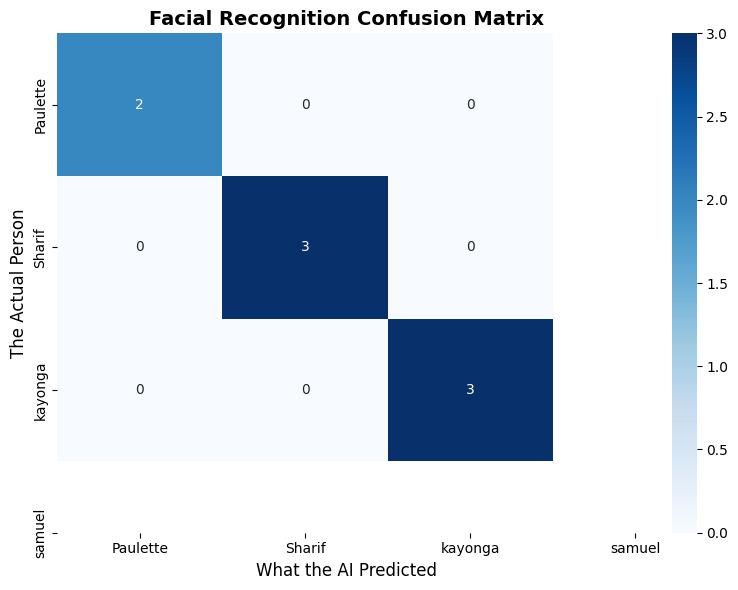

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Translate the numbers back into names
# The model outputs numbers (0, 1, 2), so we use the encoder to get the text names back
actual_names = encoder.inverse_transform(y_test)
predicted_names = encoder.inverse_transform(y_pred)

# 2. Print exactly who the AI predicted as who
print("🔍 Prediction Breakdown (Test Set):")
print("-" * 50)
for actual, predicted in zip(actual_names, predicted_names):
    # Add a green checkmark if it guessed right, or a red X if it failed
    match_icon = "Match" if actual == predicted else "FAIL"
    print(f"{match_icon} | Actual Person: {actual.ljust(15)} -> AI Guessed: {predicted}")

print("\n" + "="*50 + "\n")

# 3. Generate the Confusion Matrix Graphic
cm = confusion_matrix(y_test, y_pred)

# Grab the unique folder names (like 'paulette', 'teammate2') for the chart labels
class_labels = encoder.classes_

# Draw the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Facial Recognition Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('What the AI Predicted', fontsize=12)
plt.ylabel('The Actual Person', fontsize=12)
plt.tight_layout()
plt.show()